## 0. Setup

In [1]:
!#pip install h5py matplotlib scikit-learn opencv-python-headless

In [2]:
!mkdir -p data
!mkdir -p "4 Deep4SNet Model"
# Download the dataset and weights
!wget -q -O hvoice-fake-voice.zip "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/data/hvoice-fake-voice.zip"
!wget -q -O "4 Deep4SNet Model/model_Deep4SNet.h5" "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/4%20Deep4SNet%20Model/model_Deep4SNet.h5"
!wget -q -O "4 Deep4SNet Model/weights_Deep4SNet.h5" "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/4%20Deep4SNet%20Model/weights_Deep4SNet.h5"
# Unzip it locally
!unzip -qq -o hvoice-fake-voice.zip -d data
!rm hvoice-fake-voice.zip

# Plot stuff
!rm plots/9*
!mkdir -p plots

rm: cannot remove 'plots/9*': No such file or directory


In [3]:
# pip install torch h5py numpy matplotlib scikit-learn opencv-python-headless
import os, pathlib, glob, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import cv2, matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from collections import defaultdict

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cpu":
    torch.set_num_threads(4)   # double backprop is heavy; keep CPU threads sane
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.10.0+cu128 | device: cuda


## 1. Config & target explanation map

We follow Dombrowski et al., *"Explanations can be manipulated and geometry is to blame"* (NeurIPS 2019).

Instead of retraining the model to plant a backdoor, we **leave the weights untouched** and craft a tiny, near-invisible perturbation `δx` of a single input so that its saliency map is redirected onto an **arbitrary target map** `hᵗ`, while the network output stays (approximately) constant. Here the target is a black-and-white image reading *"this explanation has been manipulated"* in the middle of the frame.

The target map is built from any B&W image: dark ink becomes high relevance. Drop your own image at `TARGET_IMG_PATH`, or leave it unset to auto-generate the text card.

target image not found -> synthesized text card


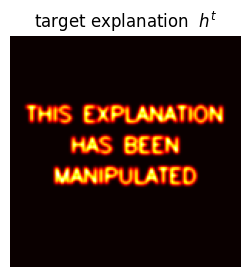

H_TARGET: (1, 1, 150, 150) | sum = 1.0


In [ ]:
IMG = 150

# ---- attack hyperparameters (input-space attack; network weights are FROZEN) --
# Loss:  L = C_EXPL*||h(x_adv)-h_t||^2  +  GAMMA*||p(x_adv)-p(x)||^2  +  TV*tv(dx)
STEPS    = 500      # iterations (early-stop usually ends sooner)
LR       = 5e-3     # Adam step size on the perturbation
EPS      = 0.0      # optional hard cap: project |dx| into [-EPS,EPS] each step (0 = off)
TIE_RGB  = True     # histograms are grayscale -> one shared dx across channels (kills rainbow speckle)
PCC_STOP = 0.85     # early stop once the explanation is close enough to the target
BETA     = 15.0     # softplus sharpness (higher = more manipulable AND more gradient signal; sweep 10-30)
# Tuning: too noisy -> raise TV, lower STEPS/LR.  Class flips -> raise GAMMA.
#         Target won't appear -> raise C_EXPL (x10) or BETA.
# ---- target explanation map ---------------------------------------------------
TARGET_IMG_PATH = "manipulated.png"                    # existing B&W image; synthesized if missing
TARGET_INVERT   = None                                 # None = auto-detect (dark ink -> salient)
TARGET_TEXT     = ("THIS EXPLANATION", "HAS BEEN", "MANIPULATED")

def text_target_image(lines=TARGET_TEXT, size=IMG, scale=0.45, thick=1, dilate=0):
    "Render BOLD centered black text on a white card. Bigger/bolder + dilated strokes"
    " -> lower spatial frequency -> far more legible as a (blobby) saliency map, and"
    " matchable with a smoother, less visible perturbation."
    canvas = np.full((size, size), 255, np.uint8)
    font   = cv2.FONT_HERSHEY_SIMPLEX
    sizes  = [cv2.getTextSize(t, font, scale, thick)[0] for t in lines]
    line_h = max(h for _, h in sizes) + int(10 * scale) + 6
    y0     = (size - line_h * len(lines)) // 2 + sizes[0][1]
    for i, t in enumerate(lines):
        (tw, _), _ = cv2.getTextSize(t, font, scale, thick)
        cv2.putText(canvas, t, ((size - tw) // 2, y0 + i * line_h), font, scale, 0, thick, cv2.LINE_AA)
    if dilate:                                            # fatten the strokes
        ink = cv2.dilate(255 - canvas, np.ones((dilate, dilate), np.uint8))
        canvas = 255 - ink
    return canvas

def build_target_map(path=TARGET_IMG_PATH, invert=TARGET_INVERT, blur=1.0):
    "Turn a B&W image into a normalized relevance target h_t of shape [1,1,IMG,IMG] (sum == 1)."
    gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE) if (path and os.path.exists(path)) else None
    if gray is None:
        gray = text_target_image(); print("target image not found -> synthesized text card")
    else:
        print(f"loaded target image: {path}")
    g = cv2.resize(gray.astype("float32"), (IMG, IMG))
    if invert is None:
        invert = g.mean() > 127.5                       # bright background -> dark ink is the signal
    if blur:
        g = cv2.GaussianBlur(g, (0, 0), blur)
    rel = (255.0 - g) if invert else g                  # salient pixels -> large values
    t = torch.tensor(np.clip(rel, 0, None))[None, None].float()
    t = t / (t.sum() + 1e-8)                            # normalize to sum 1 (paper convention)
    return t.to(DEVICE)

os.makedirs("plots", exist_ok=True)
H_TARGET = build_target_map()
plt.figure(figsize=(3, 3)); plt.imshow(H_TARGET[0, 0].cpu(), cmap="hot")
plt.title("target explanation  $h^t$"); plt.axis("off")
plt.savefig("plots/5.0 Target.png", dpi=200, bbox_inches="tight"); plt.show()
print("H_TARGET:", tuple(H_TARGET.shape), "| sum =", float(H_TARGET.sum()))

## 2. Deep4SNet as a PyTorch module

In [5]:
import h5py

class Deep4SNet(nn.Module):
    "PyTorch port of Keras Deep4SNet (single sigmoid = P(original))."
    def __init__(self, smooth=False, beta=10.0):
        super().__init__()
        self.c0 = nn.Conv2d(3, 32, 3)     # 'valid' padding == 0
        self.c1 = nn.Conv2d(32, 32, 3)
        self.c2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(18496, 64)
        self.out = nn.Linear(64, 1)
        self.smooth = smooth              # softplus instead of relu -> usable 2nd derivatives
        self.beta = beta

    def act(self, z):
        return F.softplus(z, beta=self.beta) if self.smooth else torch.relu(z)

    def forward(self, x):
        h = self.pool(self.act(self.c0(x)))
        h = self.pool(self.act(self.c1(h)))
        h = self.pool(self.act(self.c2(h)))
        h = h.permute(0, 2, 3, 1).reshape(h.size(0), -1)   # NCHW -> NHWC -> flat (Keras order)
        h = self.act(self.fc(h))
        return torch.sigmoid(self.out(h))


def load_keras_weights(model, h5_path):
    with h5py.File(h5_path, "r") as f:
        mw = f["model_weights"]
        def w(p): return np.array(mw[p])
        with torch.no_grad():
            model.c0.weight.copy_(torch.tensor(w("conv2d/conv2d/kernel:0").transpose(3,2,0,1)));      model.c0.bias.copy_(torch.tensor(w("conv2d/conv2d/bias:0")))
            model.c1.weight.copy_(torch.tensor(w("conv2d_1/conv2d_1/kernel:0").transpose(3,2,0,1)));  model.c1.bias.copy_(torch.tensor(w("conv2d_1/conv2d_1/bias:0")))
            model.c2.weight.copy_(torch.tensor(w("conv2d_2/conv2d_2/kernel:0").transpose(3,2,0,1)));  model.c2.bias.copy_(torch.tensor(w("conv2d_2/conv2d_2/bias:0")))
            model.fc.weight.copy_(torch.tensor(w("dense/dense/kernel:0").T));     model.fc.bias.copy_(torch.tensor(w("dense/dense/bias:0")))
            model.out.weight.copy_(torch.tensor(w("dense_1/dense_1/kernel:0").T)); model.out.bias.copy_(torch.tensor(w("dense_1/dense_1/bias:0")))
    return model

## 3. Get the model weights

In [6]:
import urllib.request
CANDIDATES = [
    "model_Deep4SNet.h5",
    "4 Deep4SNet Model/model_Deep4SNet.h5",
]
H5_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)

print("using weights:", H5_PATH, f"({os.path.getsize(H5_PATH)/1e6:.2f} MB)")

using weights: 4 Deep4SNet Model/model_Deep4SNet.h5 (9.76 MB)


## 4. Load + preprocess the H-Voice data

Read with OpenCV, → RGB, resize to 150×150, rescale to `[0,1]`

Labels from folder/filename: *fake* → `0`, *original* → `1`. Point `DATA_ROOT` at the unzipped dataset; folders are located by name with `rglob`, so nesting doesn't matter

In [7]:
DATA_ROOT = pathlib.Path("data/hvoice-fake-voice")
IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp"}

def locate(name):
    hits = [p for p in DATA_ROOT.rglob(name) if p.is_dir()]
    return hits[0] if hits else None

def label_of(path):
    s = (str(path.parent.name) + "/" + path.name).lower()
    if "fake" in s: return 0
    if "original" in s or "ground" in s or "truth" in s: return 1
    return None

def load_image(path):
    img = cv2.imread(str(path))
    if img is None: return None
    img = cv2.cvtColor(cv2.resize(img, (IMG, IMG)), cv2.COLOR_BGR2RGB)
    return img.astype("float32") / 255.0

def load_split(folder, limit=None):
    X, y, paths = [], [], []
    files = [p for p in sorted(folder.rglob("*")) if p.suffix.lower() in IMG_EXT]
    for p in files:
        lab = label_of(p)
        if lab is None: continue
        arr = load_image(p)
        if arr is None: continue
        X.append(arr); y.append(lab); paths.append(p)
        if limit and len(X) >= limit: break
    X = torch.tensor(np.stack(X)).permute(0, 3, 1, 2)   # NHWC -> NCHW
    return X, torch.tensor(y), paths

for n in ["Training_fake","Training_original","External_test1","External_test2"]:
    d = locate(n)
    print(f"{n:20s} -> {d if d else 'NOT FOUND'}")

Training_fake        -> data/hvoice-fake-voice/Training_fake
Training_original    -> data/hvoice-fake-voice/Training_original
External_test1       -> data/hvoice-fake-voice/External_test1
External_test2       -> data/hvoice-fake-voice/External_test2


Grab a handful of victim images to attack. The manipulation is a per-image, test-time optimization — no training set and no weight updates are needed, so a few images is plenty.

In [8]:
N_ATTACK = 5   # number of victim images to manipulate

Xf, yf, _ = load_split(locate("Training_fake"),     limit=N_ATTACK)
Xo, yo, _ = load_split(locate("Training_original"), limit=N_ATTACK)
X = torch.cat([Xf, Xo]); Y = torch.cat([yf, yo]).long()
perm = torch.randperm(len(X)); X, Y = X[perm][:N_ATTACK], Y[perm][:N_ATTACK]
print("victim images:", tuple(X.shape), "| labels:", Y.tolist())

victim images: (5, 3, 150, 150) | labels: [0, 0, 1, 1, 0]


## 5. Differentiable saliency (single-sigmoid head)

In [9]:
def saliency(model, x, y, create_graph=False):
    x = x.clone().requires_grad_(True)
    p = model(x).squeeze(1)                          # P(original)
    score = torch.where(y == 1, p, 1.0 - p).sum()    # single-sigmoid analogue of gather(1, y)
    g = torch.autograd.grad(score, x, create_graph=create_graph)[0]
    s = g.abs()
    return s / (s.flatten(1).sum(1)[:, None, None, None] + 1e-8)

def relevance(model, x, y, create_graph=False):
    "Per-pixel relevance h(x): |grad| summed over channels, normalized to sum 1. Shape [N,1,H,W]."
    x = x.clone().requires_grad_(True)
    p = model(x).squeeze(1)                          # P(original)
    score = torch.where(y == 1, p, 1.0 - p).sum()    # winning-class score (single sigmoid head)
    g = torch.autograd.grad(score, x, create_graph=create_graph)[0]
    s = g.abs().sum(1, keepdim=True)                 # collapse channels -> per-pixel relevance
    return s / (s.flatten(1).sum(1)[:, None, None, None] + 1e-8)

## 6. Preview: clean explanation vs. target

The left panel is the model's honest saliency on an unperturbed histogram; the right panel is the target card we will force it to emit. Before the attack the two share almost nothing.

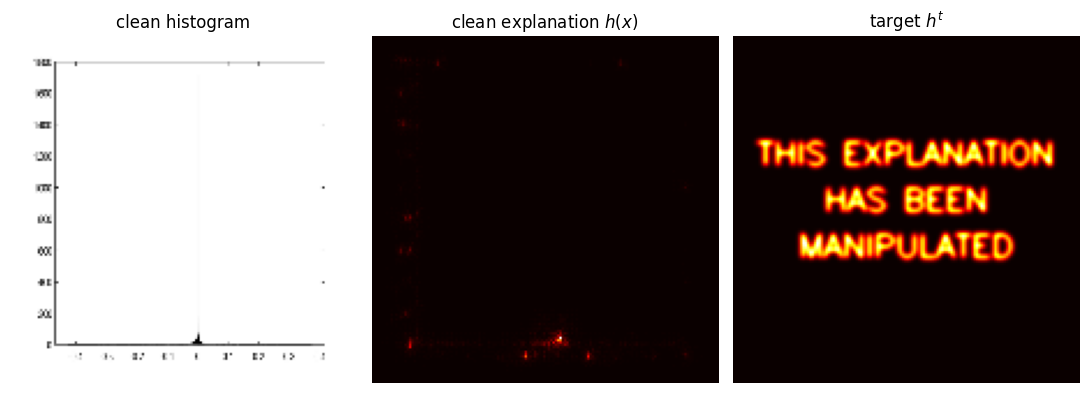

In [10]:
model_atk = load_keras_weights(Deep4SNet(smooth=True, beta=BETA), H5_PATH).to(DEVICE).eval()

xb = X[1:2].to(DEVICE)
with torch.enable_grad():
    yb = (model_atk(xb).squeeze(1) > 0.5).long()
    h0 = relevance(model_atk, xb, yb)

fig, ax = plt.subplots(1, 3, figsize=(11, 4))
ax[0].imshow(xb[0].permute(1, 2, 0).cpu());          ax[0].set_title("clean histogram")
ax[1].imshow(h0[0, 0].detach().cpu(), cmap="hot");   ax[1].set_title("clean explanation $h(x)$")
ax[2].imshow(H_TARGET[0, 0].cpu(), cmap="hot");      ax[2].set_title("target $h^t$")
for a in ax: a.axis("off")
plt.tight_layout()
plt.savefig('plots/9.1 Sanity Check.png', dpi=300, bbox_inches="tight")
plt.show()

## 7. Manipulate the explanation (input-space attack + imperceptibility toolkit)

Same method validated on VGG-16, applied to Deep4SNet. **Weights frozen**; we optimize a single perturbation δx per histogram. Softplus (Eq. 5) gives usable 2nd derivatives during the attack; final maps are re-measured on the ReLU network.

| Component | Formula | Goal |
|-----------|---------|------|
| `l_expl` | $\lVert h(x_{adv}) - h^t\rVert^2$ | manipulated explanation matches the target card |
| `l_out`  | $\lVert p(x_{adv}) - p(x)\rVert^2$ | verdict / probability stays put |
| `l_tv`   | total variation of $\delta x$ | smooth, less-grainy perturbation |

$$
\text{Loss} = (1000 \times l_{expl}) + (1.0 \times l_{out}) + (5.0 \times l_{tv})
$$

plus tied-RGB δx and an early stop at `PCC_STOP` (ie 0.85) to avoid overfitting the perturbation. The attack is run for a maximum of 500 iterations, but usually stops sooner

*Note:* Deep4SNet is a shallow 3-conv net, so per the paper's curvature bound its manipulability ceiling is **lower** than VGG's — don't expect VGG-level PCC. The VGG control already proved the loop is correct, so whatever ceiling shows up here is a capacity/domain property, not a bug.

In [ ]:
x0 = X.to(DEVICE)
with torch.no_grad():
    p0 = model_atk(x0).squeeze(1)
    y0 = (p0 > 0.5).long()                          # freeze the winning class per image

C = 1 if TIE_RGB else 3
delta = torch.zeros(x0.size(0), C, IMG, IMG, device=DEVICE).requires_grad_(True)
opt   = torch.optim.Adam([delta], LR)

def perturbed(x0, delta):
    d = delta.expand(-1, 3, -1, -1) if TIE_RGB else delta
    return (x0 + d).clamp(0.0, 1.0)                 # always a valid image in [0,1]

def tv(delta):                                       # anisotropic total variation of dx
    return (delta[:, :, 1:, :] - delta[:, :, :-1, :]).abs().mean() + \
           (delta[:, :, :, 1:] - delta[:, :, :, :-1]).abs().mean()

history = defaultdict(list)
pbar = tqdm(total=STEPS, desc="Manipulating", unit="step", leave=True)
for step in range(STEPS):
    x_adv = perturbed(x0, delta)
    h = relevance(model_atk, x_adv, y0, create_graph=True)       # [N,1,H,W], differentiable
    p = model_atk(x_adv).squeeze(1)

    l_expl = ((h - H_TARGET) ** 2).flatten(1).sum(1).mean()      # match the target card
    l_out  = ((p - p0) ** 2).mean()                              # keep the verdict constant
    l_tv   = tv(delta)                                           # smooth perturbation
    loss   = 1e4 * l_expl + 1.0 * l_out + 5.0 * l_tv

    opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        if EPS: delta.clamp_(-EPS, EPS)                          # project into the eps-ball
        pcc = torch.corrcoef(torch.stack([h.detach().flatten(1).mean(0),
                                          H_TARGET.flatten()]))[0, 1]
        dx  = float((perturbed(x0, delta) - x0).abs().mean())
        history['step'].append(step); history['l_expl'].append(l_expl.item())
        history['l_out'].append(l_out.item()); history['pcc'].append(float(pcc))
        history['dx'].append(dx)
        if step % 50 == 0 or step == STEPS - 1:
            flips = int(((p.detach() > 0.5).long() != y0).sum())
            pbar.set_postfix(pcc=f"{float(pcc):+.2f}", l_out=f"{l_out.item():.2e}",
                             dx=f"{dx:.3f}", flips=flips)
    pbar.update(1)
    if float(pcc) >= PCC_STOP:
        print(f"early stop at step {step} (PCC {float(pcc):+.3f})")
        break
pbar.close()
x_adv = perturbed(x0, delta).detach()
print("done. final PCC:", f"{history['pcc'][-1]:+.3f}", "| mean|dx|:", f"{history['dx'][-1]:.4f}")

Manipulating:   0%|          | 0/500 [00:00<?, ?step/s]

early stop at step 254 (PCC +0.850)
done. final PCC: +0.850 | mean|dx|: 0.0621


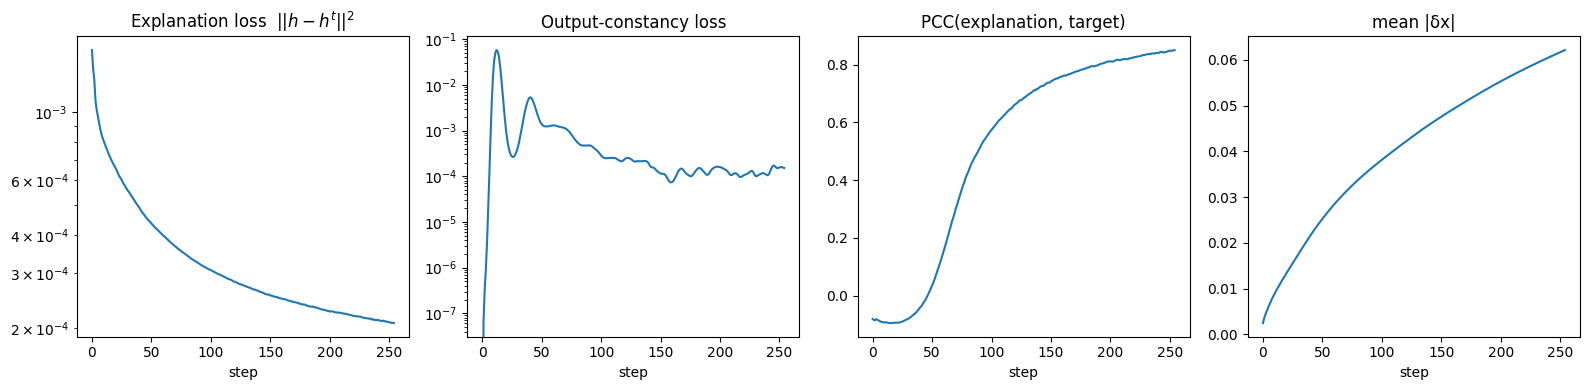

In [12]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
panels = [('l_expl', 'Explanation loss  ' + r'$||h - h^t||^2$', True),
          ('l_out',  'Output-constancy loss', True),
          ('pcc',    'PCC(explanation, target)', False),
          ('dx',     'mean |δx|', False)]
for a, (key, title, logy) in zip(ax, panels):
    a.plot(history['step'], history[key])
    if logy: a.set_yscale('log')
    a.set_xlabel('step'); a.set_title(title)
plt.tight_layout(); plt.savefig('plots/9.2 Training Loss Metrics.png', dpi=300); plt.show()

## 8. Visualize

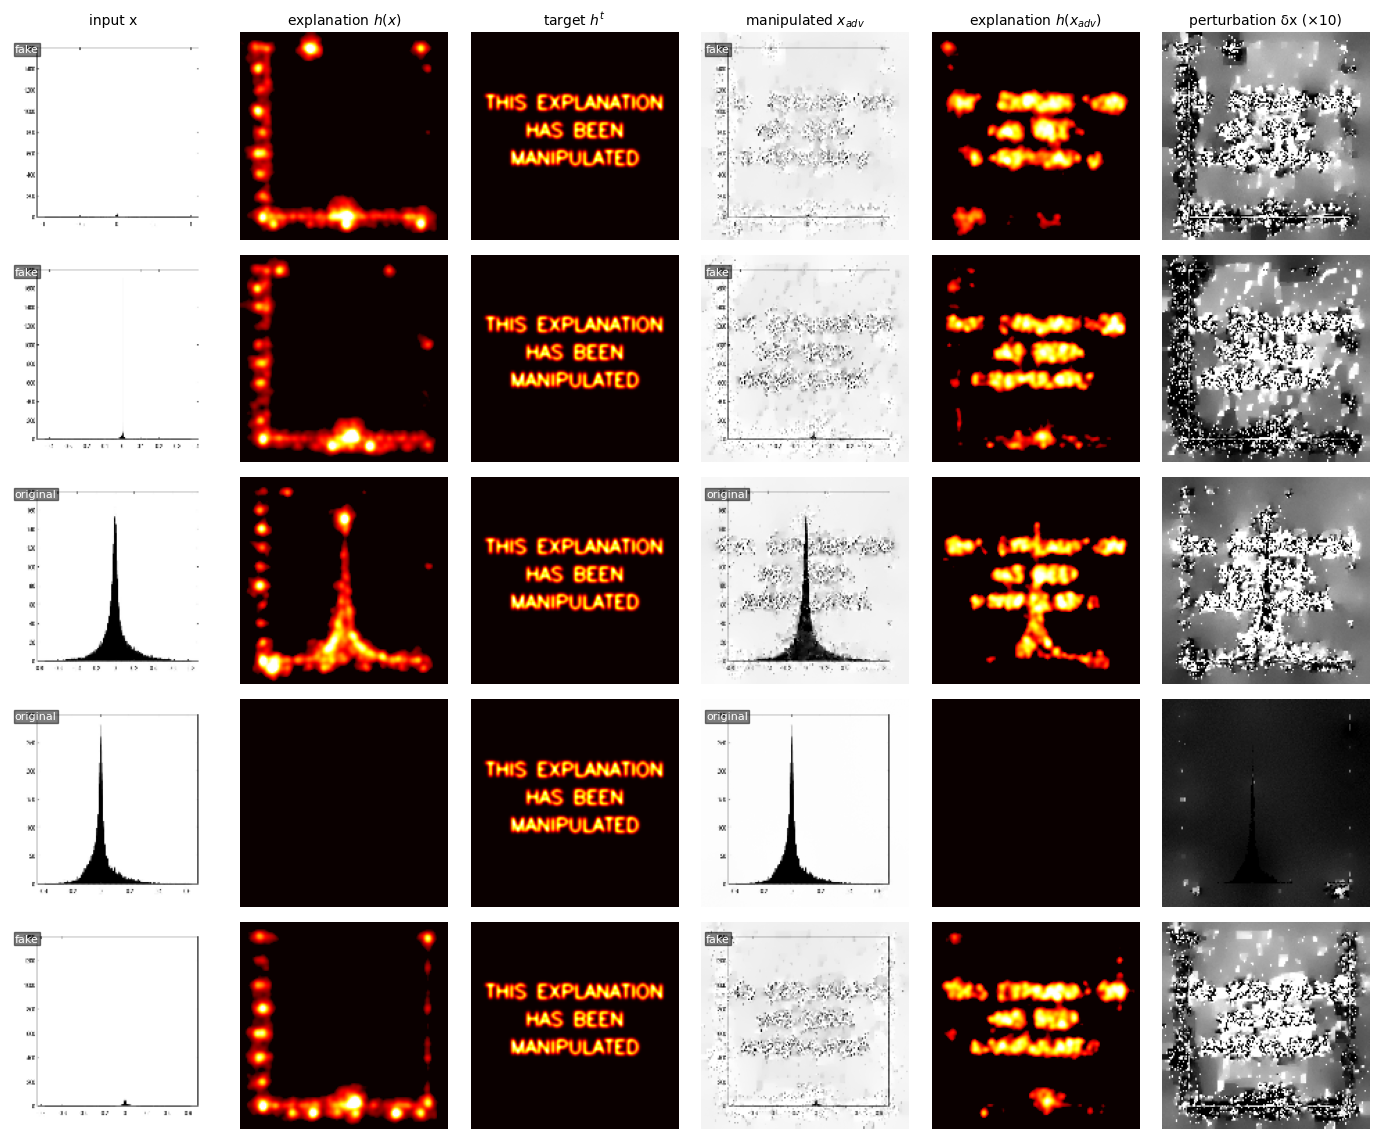

In [13]:
# paper protocol: optimize with softplus, then re-measure explanations on the ORIGINAL relu network
model_relu = load_keras_weights(Deep4SNet(smooth=False), H5_PATH).to(DEVICE).eval()

xb, xad = x0, x_adv.to(DEVICE)
with torch.enable_grad():
    y_clean = (model_relu(xb).squeeze(1)  > 0.5).long()
    y_adv   = (model_relu(xad).squeeze(1) > 0.5).long()
    h_clean = relevance(model_relu, xb,  y_clean)
    h_adv   = relevance(model_relu, xad, y_adv)
name = lambda t: "original" if t == 1 else "fake"

def show_hot(a, m):
    s = cv2.GaussianBlur(np.asarray(m).astype("float32"), (0, 0), 1.5)
    lo, hi = np.percentile(s, 80), np.percentile(s, 99.5)
    a.imshow(np.clip((s - lo) / (hi - lo + 1e-12), 0, 1) ** 0.5, cmap="hot", vmin=0, vmax=1)

def tag(a, txt):
    a.text(3, 14, txt, color="w", fontsize=8, bbox=dict(fc="k", alpha=.5, pad=1))

K = min(5, xb.size(0))
cols = ["input x", "explanation $h(x)$", "target $h^t$",
        "manipulated $x_{adv}$", "explanation $h(x_{adv})$", "perturbation δx (×10)"]
fig, ax = plt.subplots(K, 6, figsize=(14, 2.3 * K))
if K == 1: ax = ax[None]
for i in range(K):
    ax[i, 0].imshow(xb[i].permute(1, 2, 0).cpu());  tag(ax[i, 0], name(y_clean[i].item()))
    show_hot(ax[i, 1], h_clean[i, 0].detach().cpu())
    ax[i, 2].imshow(H_TARGET[0, 0].cpu(), cmap="hot")
    ax[i, 3].imshow(xad[i].permute(1, 2, 0).cpu()); tag(ax[i, 3], name(y_adv[i].item()))
    show_hot(ax[i, 4], h_adv[i, 0].detach().cpu())
    d = (xad[i] - xb[i]).abs().mean(0).cpu() * 10
    ax[i, 5].imshow(np.clip(d, 0, 1), cmap="gray")
    for j in range(6):
        ax[i, j].axis("off")
        if i == 0: ax[i, j].set_title(cols[j], fontsize=10)
plt.tight_layout(); plt.savefig("plots/9.3 Visualisation.png", dpi=300); plt.show()

In [14]:
# # Zip the plots/ dir and make it available for download
# import shutil
# shutil.make_archive('plots', 'zip', 'plots')

# import base64
# print(base64.b64encode(open('/content/plots.zip','rb').read()).decode())

In [15]:
# FOR KAGGLE
import shutil
shutil.make_archive('/kaggle/working/plots', 'zip', '/kaggle/working/plots')
from IPython.display import FileLink
FileLink('plots.zip')

/kaggle/working/plots.zip